# Sales Prediction using Python — CodeAlpha Data Science Internship
## Task 4: Sales Prediction with Advertising Data

**Environment:** `myenv` (Anaconda) · VS Code
**Dataset:** `Advertising.csv`

---

### Notebook Roadmap

| Step | Section | What we do |
|------|----------|------------|
| 1 | Setup | Import libraries |
| 2 | Data Cleaning | Load, check types, missing values, duplicates |
| 3 | EDA | Summary stats, relationships between ad spend and sales |
| 4 | Modeling | Train a regression model to predict sales |
| 5 | Evaluation & Insights | How well the model performs, what drives sales


In [17]:
# Setup 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)

---
## Step 2 — Data Cleaning


In [18]:
# 2.1  Load the dataset ─────────────────────────────────────────────────────────
df = pd.read_csv('Advertising.csv')

print('Shape:', df.shape)
df.head()

Shape: (200, 5)


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [19]:
# 2.2  Drop the redundant index column ──────────────────────────────────────────
df.drop(columns=['Unnamed: 0'], inplace=True)
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [20]:
# 2.3  Check missing values, duplicates, and data types ────────────────────────
print('Missing values:\n', df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())
print('\nData types:\n', df.dtypes)

Missing values:
 TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Duplicate rows: 0

Data types:
 TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object


---
## Step 3 — Exploratory Data Analysis (EDA)

In [21]:
# 3.1  Basic summary statistics ─────────────────────────────────────────────────
df.describe().round(2)

,TV,Radio,Newspaper,Sales
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,14.02
std,85.85,14.85,21.78,5.22
min,0.70,0.00,0.30,1.60
25%,74.38,9.98,12.75,10.38
50%,149.75,22.90,25.75,12.90
75%,218.82,36.52,45.10,17.40
max,296.40,49.60,114.00,27.00


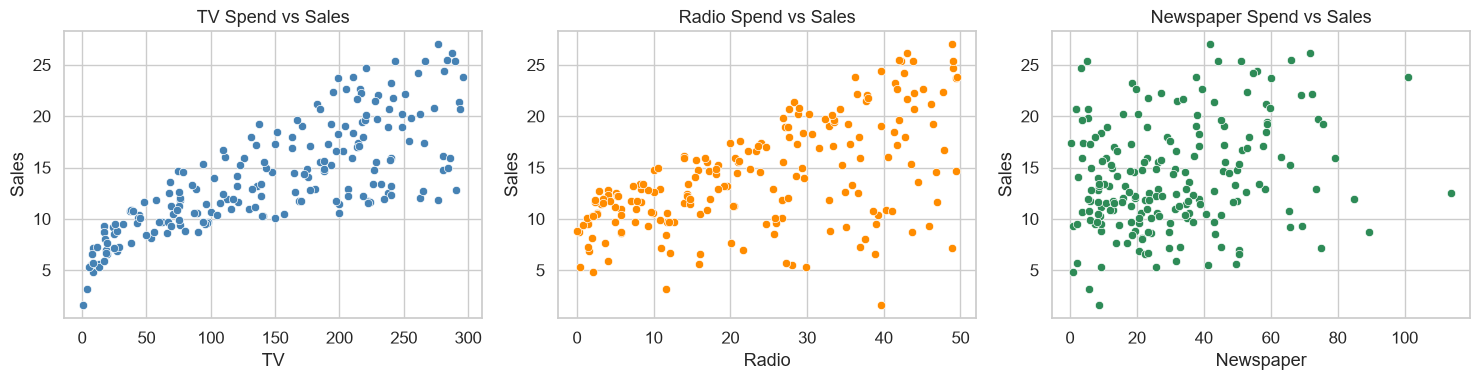

In [22]:
# 3.2  Scatter plots: each channel vs Sales ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(data=df, x='TV', y='Sales', ax=axes[0], color='steelblue')
axes[0].set_title('TV Spend vs Sales')

sns.scatterplot(data=df, x='Radio', y='Sales', ax=axes[1], color='darkorange')
axes[1].set_title('Radio Spend vs Sales')

sns.scatterplot(data=df, x='Newspaper', y='Sales', ax=axes[2], color='seagreen')
axes[2].set_title('Newspaper Spend vs Sales')

plt.tight_layout()
plt.show()

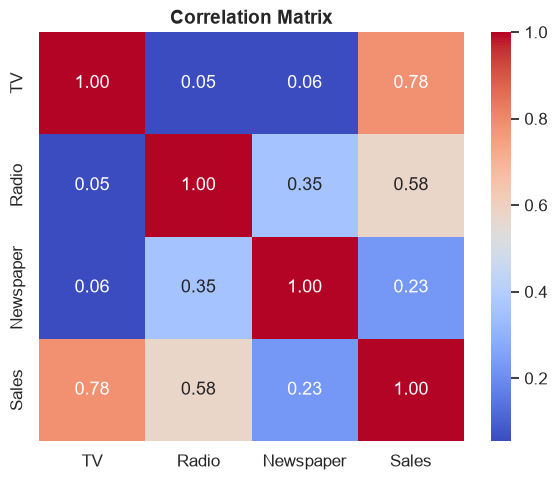

In [23]:
# 3.3  Correlation heatmap ───────────────────────────────────────────────────────
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 4 — Building the Regression Model

We'll use all three features (TV, Radio, Newspaper) to predict Sales, split the data into
training and test sets, and train a Linear Regression model.

In [24]:
# 4.1  Split data into features (X) and target (y), then train/test sets ───────
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training set:', X_train.shape)
print('Test set:', X_test.shape)

Training set: (160, 3)
Test set: (40, 3)


In [25]:
# 4.2  Train a Linear Regression model ──────────────────────────────────────────
model = LinearRegression()
model.fit(X_train, y_train)

# Show what the model learned
print('Intercept:', model.intercept_.round(3))
print('Coefficients:')
for feature, coef in zip(X.columns, model.coef_):
    print(f'  {feature}: {coef:.4f}')

Intercept: 2.979
Coefficients:
  TV: 0.0447
  Radio: 0.1892
  Newspaper: 0.0028


In [26]:
# 4.3  Predict on test data and evaluate performance ────────────────────────────
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.3f}')
print(f'Root Mean Squared Error: {rmse:.3f}')
print(f'R² Score: {r2:.3f}')

Mean Squared Error: 3.174
Root Mean Squared Error: 1.782
R² Score: 0.899


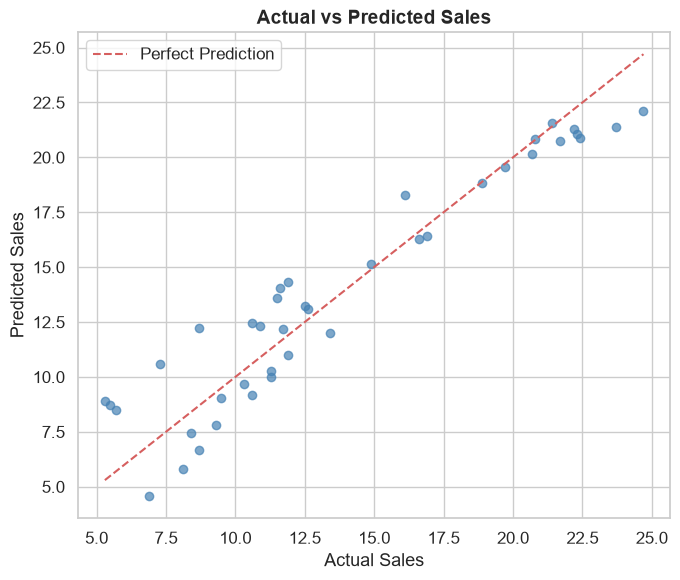

In [27]:
# 4.4  Plot predicted vs actual sales ────────────────────────────────────────────
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

---
## Step 5 — Written Insights

1. **Model performance:** The Linear Regression model explains about **90% (R² = 0.899)**
   of the variation in sales using only advertising spend across TV, Radio, and Newspaper.
   Predictions are typically accurate to within about **±1.78** sales units (RMSE), which is
   tight given sales range from roughly 1.6 to 27.

2. **TV is the strongest overall driver:** TV spend has the highest correlation with sales
   (0.78) and companies allocate by far the largest budgets to it (~$147K on average).

3. **Radio is the most cost-efficient channel:** Despite receiving a much smaller budget
   than TV (~$23K on average), Radio's regression coefficient (0.189) is over **4x higher**
   than TV's (0.045) — meaning each additional dollar spent on Radio drives noticeably more
   sales than an equivalent dollar spent on TV.

4. **Newspaper spend has minimal impact:** Both its correlation (0.23) and regression
   coefficient (0.003) are very low, suggesting newspaper advertising contributes little to
   sales in this dataset.

5. **Business recommendation:** Given Radio's outsized return per dollar, businesses may
   benefit from **reallocating some budget from Newspaper (and potentially some TV) toward
   Radio**, testing whether increased Radio investment produces proportionally higher sales
   growth. TV should remain a core channel given its strong overall relationship with sales,
   but Newspaper spend appears to be the least effective use of the advertising budget.